In [7]:
##installa dipendenze sulla destra

In [8]:
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler

In [9]:
qc = QuantumCircuit(3)
qc.h(0)
qc.cx(0, 1)
qc.cx(1,2)
qc.x(1)
qc.measure_all()

{'010': 496, '101': 528}


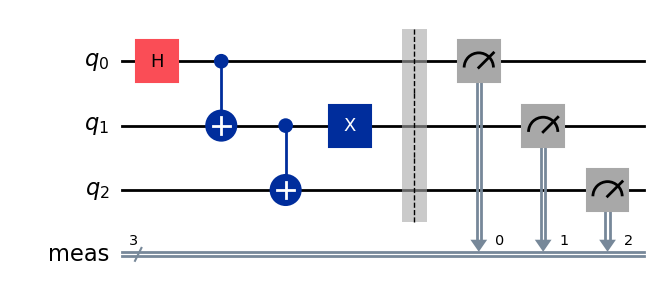

In [10]:
sampler = StatevectorSampler()
result = sampler.run([qc], shots=pow(2,10)).result()
print(result[0].data.meas.get_counts())
qc.draw("mpl")

In [11]:
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram


In [12]:
counts = result[0].data.meas.get_counts()
plot_histogram(counts)
plt.show()

In [13]:
from qiskit.circuit.library import zz_feature_map

In [14]:
features = [0.2, 0.4, 0.8]
feature_map = zz_feature_map(feature_dimension=len(features))

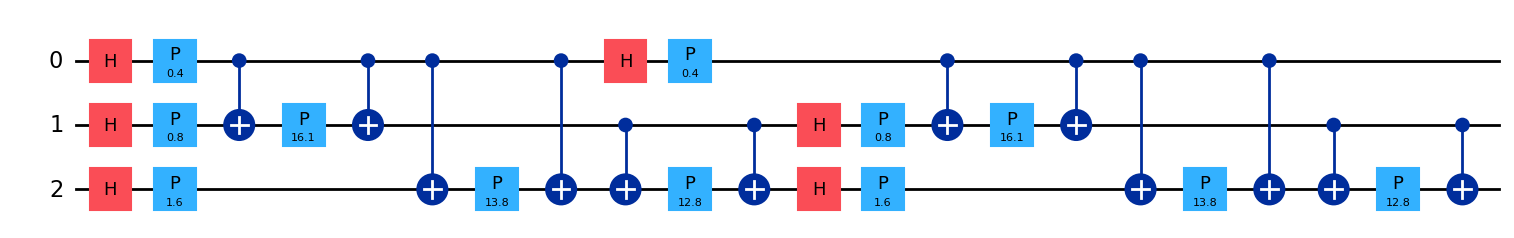

In [15]:
encoded = feature_map.assign_parameters(features)
encoded.draw("mpl")

In [21]:
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_ibm_runtime.fake_provider import FakeAuckland, FakeWashingtonV2
from qiskit.transpiler import generate_preset_pass_manager

In [49]:
backend = FakeAuckland()
ghz = QuantumCircuit(15)
ghz.h(0)
ghz.cx(0, range(1, 15))
depths = []
for seed in range(100):
    pass_manager = generate_preset_pass_manager(
        optimization_level=1,
        backend=backend,
        layout_method="trivial", # Fixed layout mapped in circuit order
        seed_transpiler=seed, # For reproducible results
    )
    depths.append(pass_manager.run(ghz).depth())

pass_manager.run(ghz).draw("mpl")

# plt.figure(figsize=(8, 6))
# plt.hist(depths, align="left", color="#AC557C")
# plt.xlabel("Depth", fontsize=14)
# plt.ylabel("Counts", fontsize=14)

SyntaxError: invalid syntax (1523413220.py, line 17)

In [55]:
from SamplerV2 import Sampler

ModuleNotFoundError: No module named 'SamplerV2'

In [67]:
from qiskit import QuantumCircuit


In [73]:
circuit = QuantumCircuit(2)
circuit.h(0)
circuit.cx(0,1)
circuit.ry(0,0,"a")
circuit.measure_all()

In [81]:
from qiskit.circuit import QuantumCircuit, Parameter

# create the parameter
phi = Parameter("theta")


In [94]:
sampler = StatevectorSampler(circuit)

TypeError: StatevectorSampler.__init__() takes 1 positional argument but 2 were given

In [93]:
job = sampler.run([transpiled_circuit])
result = job.result()
# the data bin contains one BitArray
data = result[0].data
print(f"Databin: {data}\n")
# to access the BitArray, use the key "meas", which is the default name of
# the classical register when this is added by the `measure_all` method
array = data.meas
print(f"BitArray: {array}\n")
print(f"The shape of register `meas` is {data.meas.array.shape}.\n")
print(f"The bytes in register `alpha`, shot by shot:\n{data.meas.array}\n")
# optionally, convert away from the native BitArray format to a dictionary format
counts = data.meas.get_counts()
print(f"Counts: {counts}")

/usr/local/lib/python3.12/dist-packages/qiskit/circuit/quantumcircuit.py:4721: UserWarning: Trying to add QuantumRegister to a QuantumCircuit having a layout
  circ.add_register(qreg)


Databin: DataBin(meas=BitArray(<shape=(), num_shots=1024, num_bits=2>))

BitArray: BitArray(<shape=(), num_shots=1024, num_bits=2>)

The shape of register `meas` is (1024, 1).

The bytes in register `alpha`, shot by shot:
[[0]
 [3]
 [3]
 ...
 [0]
 [0]
 [3]]

Counts: {'00': 523, '11': 501}
